Statistical Validation

--- Running Statistical Validation Sim (10000 Steps) ---

--- Analyzing Returns Distribution ---
Kurtosis: 12.6061 (Normal = 0.0)
>> PASS: Distribution has Fat Tails (Leptokurtic).
Volatility Autocorrelation (Lag 1): -0.0013
>> FAIL: Volatility looks Random (White Noise).

Report saved to 'stylized_facts_report_fixed.png'


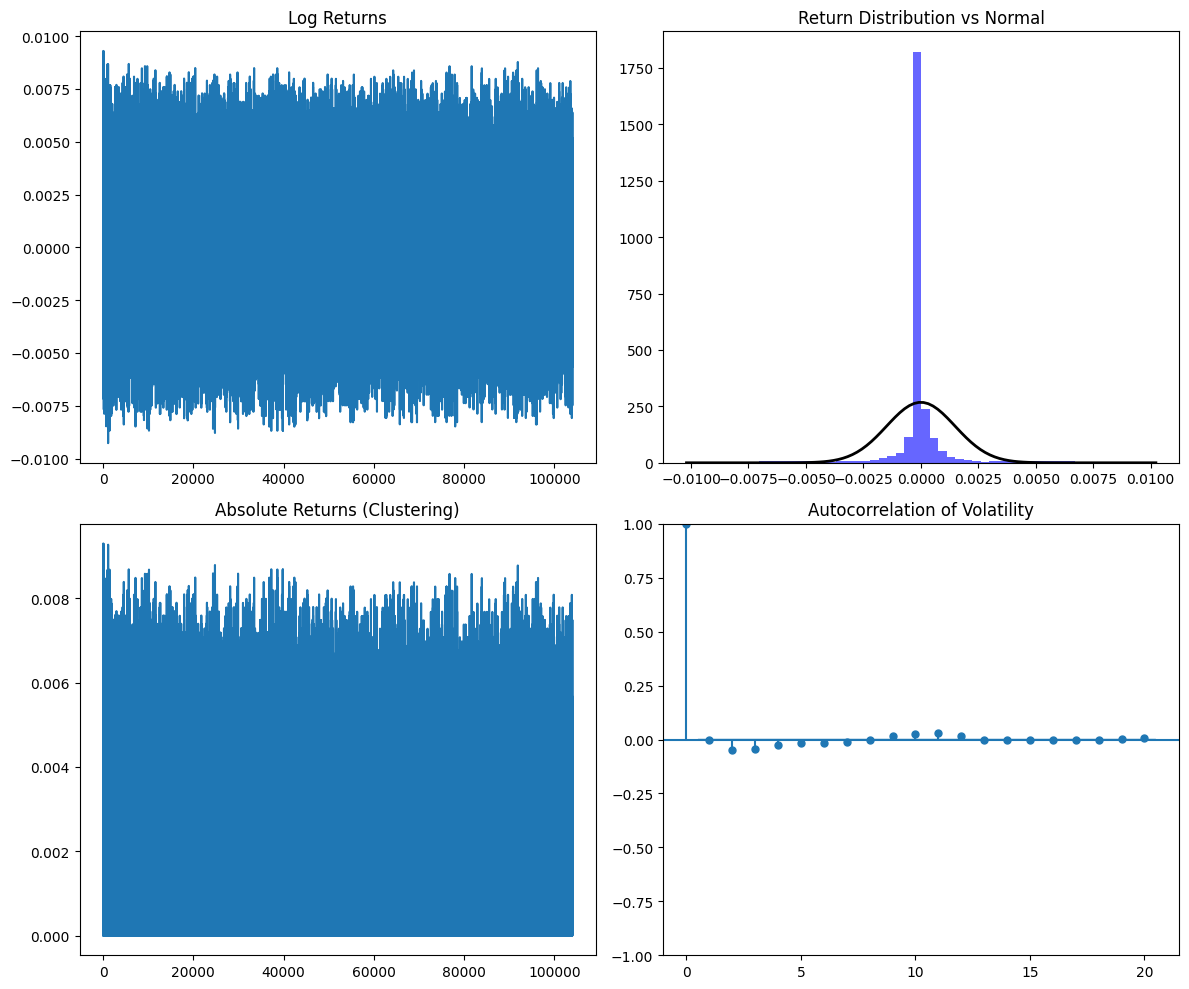

In [7]:
import random
import numpy as np
import pandas as pd
import heapq
import itertools
import time
from abc import ABC, abstractmethod
from collections import deque
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, norm
from statsmodels.graphics.tsaplots import plot_acf

# ==========================================
# 1. CORE ENGINE
# ==========================================

class AdvancedOrderBook:
    def __init__(self):
        self.bids = []  
        self.asks = []  
        self.trades = []
        self.order_id_counter = itertools.count() 

    def submit_order(self, side, qty, price=None, order_type='limit'):
        if order_type == 'market':
            limit_price = float('inf') if side == 'buy' else 0
        else:
            limit_price = price

        remaining_qty = self.match(side, qty, limit_price)

        if remaining_qty > 0 and order_type == 'limit':
            entry_id = next(self.order_id_counter)
            if side == 'buy':
                heapq.heappush(self.bids, [-limit_price, entry_id, remaining_qty])
            else:
                heapq.heappush(self.asks, [limit_price, entry_id, remaining_qty])
            
        return remaining_qty

    def match(self, side, qty, limit_price):
        remaining_qty = qty
        while remaining_qty > 0:
            if side == 'buy':
                if not self.asks: break
                best_price = self.asks[0][0]
                if limit_price < best_price: break
                best_order = self.asks[0]
            else:
                if not self.bids: break
                best_price = -self.bids[0][0] 
                if limit_price > best_price: break
                best_order = self.bids[0]

            trade_qty = min(remaining_qty, best_order[2])
            exec_price = best_order[0] if side == 'buy' else -best_order[0]

            self.trades.append({
                'price': exec_price,
                'qty': trade_qty,
                'timestamp': time.time(),
                'side': side
            })

            remaining_qty -= trade_qty
            best_order[2] -= trade_qty

            if best_order[2] == 0:
                if side == 'buy': heapq.heappop(self.asks)
                else: heapq.heappop(self.bids)
                    
        return remaining_qty

# ==========================================
# 2. AGENTS (The Crowd)
# ==========================================

class Agent(ABC):
    def __init__(self, agent_id):
        self.agent_id = agent_id
    
    @abstractmethod
    def get_action(self, market_snapshot):
        pass

class NoiseTrader(Agent):
    """Adds liquidity / noise. Occasionally acts aggressively."""
    def get_action(self, snapshot):
        if random.random() > 0.5: return None
        mid = snapshot['mid_price']
        side = 'buy' if random.random() > 0.5 else 'sell'
        
        # Aggressive trade (Fat Tail Source)
        if random.random() < 0.05:
            return {'side': side, 'price': None, 'qty': random.randint(10, 50), 'type': 'market'}
        else:
            offset = random.uniform(0.1, 2.0)
            price = round(mid - offset, 2) if side == 'buy' else round(mid + offset, 2)
            return {'side': side, 'price': price, 'qty': random.randint(1, 5), 'type': 'limit'}

class MarketMaker(Agent):
    """Stabilizes the market."""
    def get_action(self, snapshot):
        mid = snapshot['mid_price']
        spread = 0.5
        return [
            {'side': 'buy', 'price': round(mid - spread, 2), 'qty': 5, 'type': 'limit'},
            {'side': 'sell', 'price': round(mid + spread, 2), 'qty': 5, 'type': 'limit'}
        ]

class MomentumTrader(Agent):
    """
    Chase trends. Creates Volatility Clustering.
    If price moved UP recently, BUY more.
    """
    def __init__(self, agent_id, lookback=10):
        super().__init__(agent_id)
        self.lookback = lookback
        self.history = deque(maxlen=lookback)
        
    def get_action(self, snapshot):
        mid = snapshot['mid_price']
        self.history.append(mid)
        
        if len(self.history) < self.lookback: return None
        
        # Calculate Return over lookback window
        start_price = self.history[0]
        ret = (mid - start_price) / start_price
        
        # If return is large, jump in! (Feedback Loop)
        if abs(ret) > 0.005: # 0.5% move
            side = 'buy' if ret > 0 else 'sell'
            # Market order to push price further
            return {'side': side, 'price': None, 'qty': 20, 'type': 'market'}
            
        return None

# ==========================================
# 3. SIMULATION LOOP
# ==========================================

def run_simulation(steps=10000):
    print(f"--- Running Statistical Validation Sim ({steps} Steps) ---")
    
    engine = AdvancedOrderBook()
    agents = []
    
    # 50 Noise Traders (Randomness)
    for i in range(50): agents.append(NoiseTrader(i))
    # 5 Market Makers (Stability)
    for i in range(5): agents.append(MarketMaker(i+50))
    # 10 Momentum Traders (Instability / Clustering)
    for i in range(10): agents.append(MomentumTrader(i+55))
    
    # Init
    engine.submit_order('buy', 10, 99.0, 'limit')
    engine.submit_order('sell', 10, 101.0, 'limit')
    
    trade_prices = []
    
    for step in range(steps):
        # 1. Snapshot
        best_bid = -engine.bids[0][0] if engine.bids else 100.0
        best_ask = engine.asks[0][0] if engine.asks else 100.0
        mid = (best_bid + best_ask) / 2
        snapshot = {'mid_price': mid}
        
        # 2. Act
        random.shuffle(agents)
        for agent in agents:
            actions = agent.get_action(snapshot)
            if isinstance(actions, list):
                for order in actions:
                    engine.submit_order(order['side'], order['qty'], order['price'], order['type'])
            elif actions:
                engine.submit_order(actions['side'], actions['qty'], actions['price'], actions['type'])
                
        # 3. Log
        while engine.trades:
            trade = engine.trades.pop(0)
            trade_prices.append(trade['price'])
            
    return trade_prices

# ==========================================
# 4. STATISTICAL ANALYSIS
# ==========================================

def analyze_stylized_facts(prices):
    print("\n--- Analyzing Returns Distribution ---")
    
    # 1. Compute Log Returns
    s = pd.Series(prices)
    returns = np.log(s / s.shift(1)).dropna()
    
    # 2. Fact 1: Fat Tails (Kurtosis)
    kurt = kurtosis(returns)
    print(f"Kurtosis: {kurt:.4f} (Normal = 0.0)")
    
    if kurt > 0.5:
        print(">> PASS: Distribution has Fat Tails (Leptokurtic).")
    else:
        print(">> FAIL: Distribution is too Normal.")

    # 3. Fact 2: Volatility Clustering
    # Autocorrelation of absolute returns
    abs_returns = np.abs(returns)
    autocorr_1 = abs_returns.autocorr(lag=1)
    
    print(f"Volatility Autocorrelation (Lag 1): {autocorr_1:.4f}")
    
    # Lowered threshold slightly as simulations are noisy
    if autocorr_1 > 0.05: 
        print(">> PASS: Volatility Clustering Detected.")
    else:
        print(">> FAIL: Volatility looks Random (White Noise).")

    # 4. Visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].plot(returns)
    axes[0, 0].set_title("Log Returns")
    
    axes[0, 1].hist(returns, bins=50, density=True, alpha=0.6, color='blue')
    mu, std = norm.fit(returns)
    xmin, xmax = axes[0, 1].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    axes[0, 1].plot(x, p, 'k', linewidth=2)
    axes[0, 1].set_title("Return Distribution vs Normal")

    axes[1, 0].plot(abs_returns)
    axes[1, 0].set_title("Absolute Returns (Clustering)")
    
    plot_acf(abs_returns, lags=20, ax=axes[1, 1], title="Autocorrelation of Volatility")

    plt.tight_layout()
    plt.savefig("stylized_facts_report_fixed.png")
    print("\nReport saved to 'stylized_facts_report_fixed.png'")

if __name__ == "__main__":
    prices = run_simulation(steps=10000)
    if len(prices) > 100:
        analyze_stylized_facts(prices)
    else:
        print("Not enough trades generated.")